## Preparar entorno en Colab (nuestro notebook)
En esta primera fase, inicializamos nuestro motor de análisis (Pandas, Plotly, Seaborn y más) para que en todo nuestro notebook podamos trabajar de manera correcta

In [ ]:
# Instalar librerías necesarias
!pip install pyxlsb openpyxl

In [ ]:
# Importar librerías
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Si usas Google Drive, monta y cambia la ruta
from google.colab import drive, files
drive.mount('/content/drive')

Mounted at /content/drive


##3- Limpieza individual de cada dataset

### 3.1 Limpieza Morbilidad

Queremos filtrar enfermedades gastrointestinales de todo el anuario de morbilidad del ya que estos son los fenomenos biologicos mas relacionados con enfermedad por contaminacion de agua:

# Estudio de Patógenos Gastrointestinales

Este resumen detalla las principales infecciones sistémicas e intestinales causadas por bacterias y parásitos.

### Cuadro Comparativo de Infecciones

| Enfermedad | Agente Causal | Tipo de Agente | Síntomas Principales |
| :--- | :--- | :--- | :--- |
| **Fiebre Tifoidea** | *Salmonella typhi* | Bacteria | Fiebre alta constante, dolor abdominal, cefalea y malestar general. |
| **Cólera** | *Vibrio cholerae* | Bacteria | Diarrea acuosa profusa, vómitos y deshidratación severa. |
| **Giardiasis** | *Giardia lamblia* | Parásito | Diarrea, gases, náuseas y dolor estomacal (frecuente en niños). |
| **Shigelosis** | *Shigella* | Bacteria | Diarrea severa (con sangre), fiebre y calambres abdominales. |
| **Amebiasis** | *Entamoeba histolytica* | Parásito | Dolor abdominal, heces con sangre; puede ser asintomática. |

---

### Conceptos Clave

> **Protozoarios:** Son microorganismos eucariotas unicelulares. Generalmente son microscópicos y habitan en ambientes húmedos, acuáticos o actúan como parásitos dentro de un huésped.

---
*Nota: Todas estas patologías comparten la vía de transmisión **fecal-oral**, principalmente a través de agua o alimentos contaminados.*

In [ ]:
# Definimos las palabras clave para temas gastrointestinales
palabras_clave = 'intestinal|cólera|tifoidea|giardiasis|shigelosis|amebiasis'

# Filtramos el DataFrame
df_gi = df_morb[df_morb['DES_DIAGNO'].str.contains(palabras_clave, case=False, na=False)]

# Seleccionamos solo las columnas que nos interesan
resultado = df_gi[['DES_ESTADO', 'DES_DIAGNO', 'CVE_CIE10']]

# Imprimimos el resultado, agrupamos por estado y mostramos los diagnósticos encontrados
for estado, grupo in resultado.drop_duplicates().groupby('DES_ESTADO'):
    print(f"\n📍 ESTADO: {estado}")
    for _, fila in grupo.iterrows():
        print(f"   - {fila['DES_DIAGNO']}: {fila['CVE_CIE10']}")
    print("-" * 30)


📍 ESTADO: Aguascalientes
   - Cólera: A00
   - Amebiasis intestinal: A06.0-A06.3, A06.9
   - Shigelosis: A03
   - Fiebre tifoidea: A01.0
   - Giardiasis: A07.1
   - Infecciones intestinales por otros organismos y las mal definidas: A04, A08-A09 excepto A08.0
   - Fiebre paratifoidea: A01.1-A01.4
   - Otras infecciones intestinales debidas a protozoarios: A07.0, A07.2, A07.9
------------------------------

📍 ESTADO: Baja California
   - Cólera: A00
   - Amebiasis intestinal: A06.0-A06.3, A06.9
   - Shigelosis: A03
   - Fiebre tifoidea: A01.0
   - Giardiasis: A07.1
   - Infecciones intestinales por otros organismos y las mal definidas: A04, A08-A09 excepto A08.0
   - Fiebre paratifoidea: A01.1-A01.4
   - Otras infecciones intestinales debidas a protozoarios: A07.0, A07.2, A07.9
------------------------------

📍 ESTADO: Baja California Sur
   - Cólera: A00
   - Amebiasis intestinal: A06.0-A06.3, A06.9
   - Shigelosis: A03
   - Fiebre tifoidea: A01.0
   - Giardiasis: A07.1
   - Infeccione

In [ ]:
#Estandarizamos la columna nombre de estado a como lo estamos trabajando
df_morb = df_morb.rename(columns={'DES_ESTADO': 'NOM_ESTADO'})

# Definimos los diagnósticos de interés basandonos en nuestra lista filtrada de la celda anterior
diagnosticos_gi = [
    'Cólera',
    'Amebiasis intestinal',
    'Shigelosis',
    'Fiebre tifoidea',
    'Giardiasis',
    'Infecciones intestinales por otros organismos y las mal definidas',
    'Fiebre paratifoidea',
    'Otras infecciones intestinales debidas a protozoarios'
]

# Filtramos el DataFrame original para quedarnos solo con estas enfermedades
df_gi_filtrado = df_morb[df_morb['DES_DIAGNO'].isin(diagnosticos_gi)]

# Calculamos el total nacional (suma de todos los estados y enfermedades)
total_casos = df_gi_filtrado['ACUMULADO'].sum()

# Agrupamos por diagnóstico para ver cuáles son las más frecuentes
resumen_por_enfermedad = df_gi_filtrado.groupby('DES_DIAGNO')['ACUMULADO'].sum().sort_values(ascending=False)

# Guardar en la carpeta temporal de Colab
df_gi_filtrado.to_csv('/content/enfermedades_gi_filtrado.csv', index=False, encoding='utf-8-sig')

print(f"TOTAL GENERAL DE ENFERMEDADES GI REGISTRADAS: {total_casos:,}")
print("\nDesglose por enfermedad:")
print(resumen_por_enfermedad)

TOTAL GENERAL DE ENFERMEDADES GI REGISTRADAS: 6,152,960

Desglose por enfermedad:
DES_DIAGNO
Infecciones intestinales por otros organismos y las mal definidas    5771681
Amebiasis intestinal                                                  227409
Otras infecciones intestinales debidas a protozoarios                  78333
Fiebre tifoidea                                                        45280
Giardiasis                                                             13334
Fiebre paratifoidea                                                    12458
Shigelosis                                                              4465
Cólera                                                                     0
Name: ACUMULADO, dtype: int64


/tmp/ipykernel_19952/1642014864.py:12: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




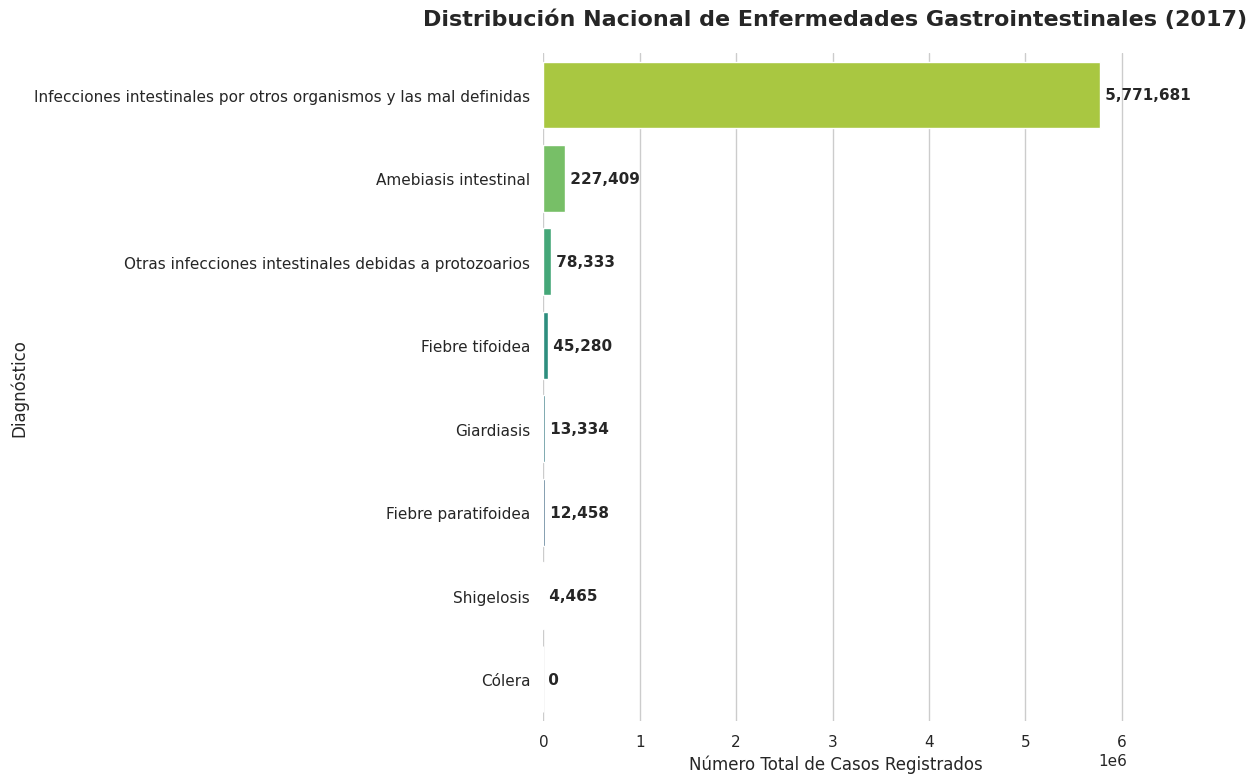

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Crear la paleta de colores
paleta = sns.color_palette("viridis_r", len(resumen_por_enfermedad))

# Crear el gráfico de barras horizontales
plot = sns.barplot(
    x=resumen_por_enfermedad.values,
    y=resumen_por_enfermedad.index,
    palette=paleta
)

# Añadir etiquetas de datos
for i, valor in enumerate(resumen_por_enfermedad.values):
    plt.text(valor, i, f' {valor:,.0f}', va='center', fontsize=11, fontweight='bold')

# Personalizar títulos y ejes
plt.title('Distribución Nacional de Enfermedades Gastrointestinales (2017)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Número Total de Casos Registrados', fontsize=12)
plt.ylabel('Diagnóstico', fontsize=12)

# Limpiar los bordes
sns.despine(left=True, bottom=True)

# Ajustar diseño y mostrar
plt.tight_layout()
plt.show()

### 3.2 Limpieza ITER (INEGI) Censo de Población y Vivienda 2020
## Diccionario de Variables Seleccionadas (ITER 2020)

Para el análisis de la relación entre infraestructura hídrica y salud pública, hemos filtrado las siguientes variables del **Censo de Población y Vivienda 2020** que nos aportan informacion para nuestro analisis de contaminacion de agua y son las siguientes:

---

### Ubicación y Demografía
* **`NOM_ENT`**: Nombre oficial de la entidad federativa.
* **`NOM_MUN`**: Nombre oficial del municipio o demarcación territorial.
* **`NOM_LOC`**: Nombre con el que se reconoce a la localidad.
* **`POBTOT`**: Total de personas que residen habitualmente en la localidad.

### Infraestructura de Agua (Abastecimiento)
* **`VPH_AGUADV`**: Viviendas que disponen de agua entubada dentro de la vivienda o en el terreno (patio o solar).
* **`VPH_AEASP`**: Viviendas que disponen de agua entubada y se abastecen del **servicio público** de agua.
* **`VPH_AGUAFV`**: Viviendas que **no disponen de agua entubada** en el ámbito de la vivienda (acarreo externo).

### Saneamiento y Drenaje
* **`VPH_DRENAJ`**: Viviendas que disponen de drenaje conectado a la red pública, fosa séptica, tubería a barranca o río.
* **`VPH_NODREN`**: Viviendas que **no disponen de drenaje**.
* **`VPH_EXCSA`**: Viviendas que disponen de excusado o sanitario.
* **`VPH_LETR`**: Viviendas que disponen de letrina (pozo u hoyo).

### Almacenamiento y Vulnerabilidad
* **`VPH_TINACO`**: Viviendas que disponen de tinaco para almacenamiento de agua.
* **`VPH_CISTER`**: Viviendas que disponen de cisterna o aljibe.
* **`VPH_C_SERV`**: Viviendas que disponen de los tres servicios básicos simultáneamente: energía eléctrica, agua entubada de la red pública y drenaje.
* **`VPH_NDEAED`**: Viviendas que **no disponen** de energía eléctrica, ni agua entubada, ni drenaje.

---
> **Fuente:** Instituto Nacional de Estadística y Geografía (INEGI). Censo de Población y Vivienda 2020.

In [ ]:
# Definir la lista de columnas
cols_analisis = [
    'NOM_ENT', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC',
    'POBTOT',
    'VPH_AGUADV', 'VPH_AEASP', 'VPH_AGUAFV',
    'VPH_DRENAJ', 'VPH_NODREN',
    'VPH_TINACO', 'VPH_CISTER',
    'VPH_EXCSA', 'VPH_LETR',
    'VPH_C_SERV', 'VPH_NDEAED'
]

# Filtrar y limpiar datos numéricos
df_iter_agua = df_iter[cols_analisis].copy()

#Estandarizamos la columna nombre de estado a como lo estamos trabajando
df_iter_agua.rename(columns={'NOM_ENT': 'NOM_ESTADO'}, inplace=True)

#Limpiamos datos numericos
cols_numericas = ['POBTOT', 'VPH_AGUADV', 'VPH_AEASP', 'VPH_AGUAFV',
                  'VPH_DRENAJ', 'VPH_NODREN', 'VPH_TINACO', 'VPH_CISTER',
                  'VPH_EXCSA', 'VPH_LETR', 'VPH_C_SERV', 'VPH_NDEAED']

for col in cols_numericas:
    df_iter_agua[col] = pd.to_numeric(df_iter_agua[col], errors='coerce').fillna(0)

# Guardar el resultado
df_iter_agua.to_csv('/content/iter_analisis_agua_limpio.csv', index=False, encoding='utf-8-sig')

print("Dataset corregido y guardado exitosamente")

Dataset corregido y guardado exitosamente


In [ ]:
# Extraer los datos del Total Nacional
# En el archivo del ITER, la primera fila (índice 0) siempre es el resumen de todo el país.
datos_nacionales_viviendas = df_iter_agua.iloc[0]

# Calcular el universo total de viviendas para este análisis
# (Viviendas con agua + Viviendas sin agua)
total_viviendas = datos_nacionales_viviendas['VPH_AGUADV'] + datos_nacionales_viviendas['VPH_AGUAFV']

# Calcularemos los porcentajes
# General
pct_con_agua = (datos_nacionales_viviendas['VPH_AGUADV'] / total_viviendas) * 100
pct_sin_agua = (datos_nacionales_viviendas['VPH_AGUAFV'] / total_viviendas) * 100

# Desglose por fuente
# AEASP: Red pública
# (AGUADV - AEASP): Otras fuentes entubadas (pozos, etc.)
red_publica = datos_nacionales_viviendas['VPH_AEASP']
otras_fuentes = datos_nacionales_viviendas['VPH_AGUADV'] - datos_nacionales_viviendas['VPH_AEASP']
sin_acceso = datos_nacionales_viviendas['VPH_AGUAFV']

pct_red_publica = (red_publica / total_viviendas) * 100
pct_otras_fuentes = (otras_fuentes / total_viviendas) * 100
pct_ninguna = (sin_acceso / total_viviendas) * 100

# Imprimimos resultados
print(f"TOTAL VIVIENDAS ANALIZADAS: {total_viviendas:,.0f}")
print(f"Con acceso entubado: {pct_con_agua:.2f}%")
print(f"Sin acceso entubado: {pct_sin_agua:.2f}%")

TOTAL VIVIENDAS ANALIZADAS: 35,073,836
Con acceso entubado: 96.53%
Sin acceso entubado: 3.47%


/tmp/ipykernel_19952/624161431.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




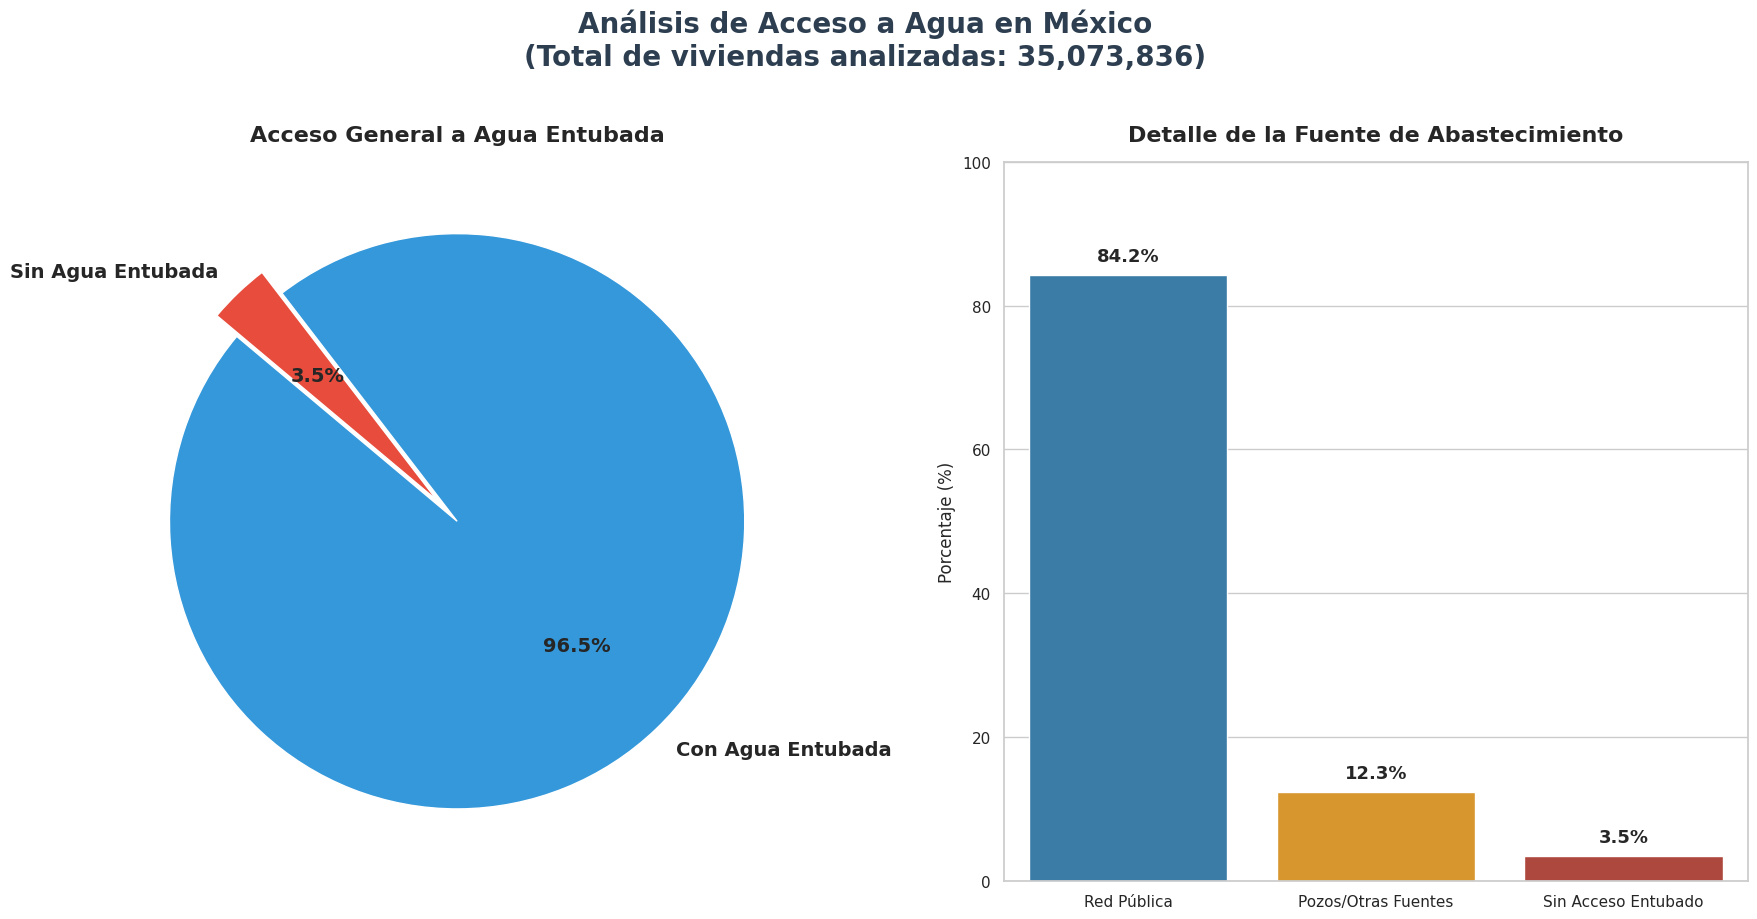

In [ ]:
# Generamos Graficas
sns.set_theme(style="whitegrid")

# Creamos la figura
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 9))


fig.suptitle(f'Análisis de Acceso a Agua en México\n(Total de viviendas analizadas: {total_viviendas:,.0f})',
             fontsize=20, fontweight='bold', color='#2c3e50', y=1.02)

# Gráfica 1: Distribución General
labels1 = ['Con Agua Entubada', 'Sin Agua Entubada']
values1 = [pct_con_agua, pct_sin_agua]
colors1 = ['#3498db', '#e74c3c']

ax1.pie(values1, labels=labels1, autopct='%1.1f%%', startangle=140,
        colors=colors1, explode=(0, 0.1), textprops={'fontsize': 14, 'fontweight': 'bold'})
ax1.set_title('Acceso General a Agua Entubada', fontsize=16, fontweight='bold', pad=15)

# Gráfica 2: Detalle por Fuente de Abastecimiento
access_labels = ['Red Pública', 'Pozos/Otras Fuentes', 'Sin Acceso Entubado']
access_values = [pct_red_publica, pct_otras_fuentes, pct_ninguna]
access_colors = ['#2980b9', '#f39c12', '#c0392b']

sns.barplot(x=access_labels, y=access_values, palette=access_colors, ax=ax2)
ax2.set_title('Detalle de la Fuente de Abastecimiento', fontsize=16, fontweight='bold', pad=15)
ax2.set_ylabel('Porcentaje (%)', fontsize=12)
ax2.set_ylim(0, 100)

# Añadir etiquetas de porcentaje sobre las barras
for i, v in enumerate(access_values):
    ax2.text(i, v + 2, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Ajustar el diseño para que no se encimen los títulos
plt.tight_layout()
plt.show()

### 3.3 Limpieza CONEVAL (Pobreza)

In [ ]:
# Diccionario de Estandarización
mapa_de_renombre = {
    'clave_entidad': 'CVE_ESTADO',
    'entidad_federativa': 'NOM_ESTADO',
    'clave_municipio': 'MUN',
    'municipio': 'NOM_MUN',
    'grupo': 'AMBITO',
    'poblacion': 'POB_TOTAL',
    'pobreza_porcentaje': 'PCT_POBREZA',
    'carencia_servicios_basicos_vivienda_porcentaje': 'PCT_Carencia_Servicios_Basicos_Vivienda',
    'carencia_calidad_espacios_vivienda_porcentaje': 'PCT_Carencia_Calidad_Espacio_Vivienda',
    'carencia_servicios_de_salud_porcentaje': 'PCT_Carencia_Servicios_Salud'
}

# Filtrar y Renombrar
df_pobreza_limpio = df_pobreza[list(mapa_de_renombre.keys())].copy()
df_pobreza_limpio.rename(columns=mapa_de_renombre, inplace=True)

# Limpieza de valores nulos del CONEVAL (-999 significa dato no disponible)
df_pobreza_limpio.replace(-999.0, np.nan, inplace=True)

# Limpiar el texto de la columna AMBITO
df_pobreza_limpio['AMBITO'] = df_pobreza_limpio['AMBITO'].str.replace('Ámbito de residencia: ', '', regex=False)

# Guardar el nuevo CSV
df_pobreza_limpio.to_csv('/content/pobreza_analisis_agua_limpio.csv', index=False, encoding='utf-8-sig')

print("Dataset de pobreza estandarizado y guardado.")


Dataset de pobreza estandarizado y guardado.


### 3.4 Limpieza CONAGUA
En México, la gran mayoría de las comunidades rurales y muchas urbanas dependen directamente de pozos y acuíferos para su consumo diario. Si el agua subterránea está contaminada (por arsénico, fluoruros o coliformes), el impacto en la salud es crónico y directo.

Escogimos las siguientes mediciones de la CONAGUA porque nos aportan informacion al analisis de contaminacion de agua y su consumo diario:

**1. El Archivo Imprescindible: Subterráneo (D)**

Este es muy importante para nosotros son los cenotes, galerías y manantiales.

* Por qué: En México, la gran mayoría de las comunidades rurales y muchas urbanas dependen directamente de pozos y acuíferos para su consumo diario. Si el agua subterránea está contaminada (por arsénico, fluoruros o coliformes), el impacto en la salud es crónico y directo.

* Hallazgo potencial: Podemos cruzar la contaminación de acuíferos con las zonas de alta pobreza que dependen de pozos (del dataset del INEGI que limpiamos) para demostrar un "riesgo invisible" que empobrece a las familias por gastos en salud.

**2. El Archivo Estratégico: Lótico (A)**

Los ríos, riachuelos y arroyos.

* Por qué: Son los receptores principales de las descargas de aguas residuales industriales y municipales. Son cuerpos de agua en movimiento que atraviesan múltiples comunidades.

* Hallazgo potencial: Identificar "corredores de enfermedad" donde un río contaminado atraviesa municipios con alta incidencia de enfermedades gastrointestinales (los datos de morbilidad que ya tenemos).

**3. El Archivo de Soporte: Léntico (B)**

Presas y lagos.

* Por qué: Muchas de estas son fuentes de abastecimiento para grandes ciudades (como el sistema Cutzamala).

* Hallazgo potencial: Evidenciar que incluso el agua almacenada para las ciudades presenta grados de contaminación que elevan los costos de tratamiento.

##¿En que enfocarnos?
1. Microbiológicos (Causantes directos de enfermedades gastrointestinales): COLI_FEC (Coliformes fecales), COLI_TOT (Coliformes totales), E_COLI, ENTEROC_FEC. Estos son el argumento principal para los problemas de salud inmediatos.

2. Indicadores de Saneamiento Deficiente (Aguas residuales no tratadas): DBO_TOT (Demanda Biológica de Oxígeno), DQO_TOT (Demanda Química de Oxígeno), SST (Sólidos Suspendidos Totales). Indican qué tan sucia está el agua orgánicamente.

2. Metales Pesados (Salud a largo plazo): AS_TOT (Arsénico), PB_TOT (Plomo), HG_TOT (Mercurio), CD_TOT (Cadmio).



In [ ]:
# Cargar los datasets
df_sitios_conagua = pd.read_csv('Sitios.csv', encoding='utf-8')
df_resultados_conagua = pd.read_csv('Resultados.csv', encoding='utf-8')

# Limpieza de Sitios: Quitar cuerpos de agua costeros
sitios_filtrados = df_sitios_conagua[~df_sitios_conagua['TIPO DE CUERPO DE AGUA'].astype(str).str.contains('COSTER', case=False, na=False)]

# Selección de columnas de Resultados
columnas_base = ['CLAVE SITIO', 'FECHA REALIZACIÓN', 'Año']

cols_microbiologicas = ['COLI_FEC', 'COLI_TOT', 'E_COLI', 'ENTEROC_FEC']

# Columnas de calidad del agua e impacto de la falta de saneamiento (ODS 6)
cols_calidad_saneamiento = ['DBO_TOT', 'DQO_TOT', 'SST', 'TURBIEDAD']

# Metales pesados (Tóxicos)
cols_metales = ['AS_TOT', 'PB_TOT', 'HG_TOT', 'CD_TOT']

# Juntamos la lista de columnas y verificamos que existan en el CSV
columnas_deseadas = columnas_base + cols_microbiologicas + cols_calidad_saneamiento + cols_metales
columnas_a_mantener = [col for col in columnas_deseadas if col in df_resultados_conagua.columns]

# Filtramos el dataframe de resultados
resultados_filtrados = df_resultados_conagua[columnas_a_mantener]

# Unir (Merge) Resultados limpios con Sitios limpios
# Hacemos un 'inner' join para quedarnos SOLO con los registros que no son costeros
# y traernos la información de ubicación geográfica que servirá para INEGI/CONEVAL
df_conagua_limpio = pd.merge(
    resultados_filtrados,
    sitios_filtrados[['CLAVE SITIO', 'NOMBRE DEL SITIO', 'ESTADO', 'MUNICIPIO', 'LATITUD', 'LONGITUD', 'TIPO DE CUERPO DE AGUA']],
    on='CLAVE SITIO',
    how='inner'
)

#Estandarizamos la columna nombre de estado a como lo estamos trabajando
#df_conagua_limpio = df_conagua_limpio.rename(columns={'ESTADO': 'NOM_ESTADO'})

# Estandarizar nombres de estados y municipios
df_conagua_limpio['ESTADO'] = df_conagua_limpio['ESTADO'].str.upper().str.strip()
df_conagua_limpio['MUNICIPIO'] = df_conagua_limpio['MUNICIPIO'].str.upper().str.strip()

# Guardar el nuevo csv limpio
df_conagua_limpio.to_csv('/content/CONAGUA_Limpio.csv', index=False, encoding='utf-8')

# Ver las primeras filas de nuestro dataset listo para el análisis
print(f"Total de registros limpios: {df_conagua_limpio.shape}")

/tmp/ipykernel_19952/1449999126.py:3: DtypeWarning:

Columns (4,6,7,8,9,10,11,12,15,16,17,18,19,24,25,26,27,28,29,30,31,32,33,34,35,38,39,40,41,42,43,45,46,47,48,49,51,52,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166,167,168,169,170,171,172,173,174,175,176,177,178,179,180,181,182,183,184,185,186,187,188,189,190,191,192,193,194,195,196,197,198,199,200,201,202,203,204,205,206,207,208,209,210,211,212,213,214,215,216,217,218,219,220,222,223,224,225,226,227,228,230,231,232,233,234,235,236,237,238,239,240,241,242,243,244,245,246,255,258,261,262,263,264,265,266,267,268,269,270,271,272,273,274,275,276,277,278,279,280,281,282,283,284,285,286,287,288,

Total de registros limpios: (99086, 21)


### 3.5 Datasets Limpios

In [ ]:
ruta = '/content/drive/MyDrive/IIMAS/Hackathon/DatosLimpios'
archivos = [f for f in os.listdir(ruta) if f.endswith(('.xlsx', '.xls', '.csv', '.xlsb'))]

print(f"Procesando {len(archivos)} archivos...\n")

for archivo in archivos:
    path_completo = os.path.join(ruta, archivo)
    try:
        if archivo.endswith('.csv'):
            try:
                # Intento 1: Estándar UTF-8
                df_headers = pd.read_csv(path_completo, nrows=0)
            except UnicodeDecodeError:
                # Intento 2: Codificación para español (Latin-1)
                df_headers = pd.read_csv(path_completo, nrows=0, encoding='latin-1')

        elif archivo.endswith('.xlsb'):
            df_headers = pd.read_excel(path_completo, engine='pyxlsb', nrows=0)

        else:
            df_headers = pd.read_excel(path_completo, nrows=0)

        print(f"📄 Archivo: {archivo}")
        print(f"📊 Columnas: {df_headers.columns.tolist()}")
        print("-" * 50)

    except Exception as e:
        print(f"Error persistente al leer {archivo}: {e}")

Procesando 4 archivos...

📄 Archivo: pobreza_analisis_agua_limpio.csv
📊 Columnas: ['CVE_ESTADO', 'NOM_ESTADO', 'MUN', 'NOM_MUN', 'AMBITO', 'POB_TOTAL', 'PCT_POBREZA', 'PCT_Carencia_Servicios_Basicos_Vivienda', 'PCT_Carencia_Calidad_Espacio_Vivienda', 'PCT_Carencia_Servicios_Salud']
--------------------------------------------------
📄 Archivo: iter_analisis_agua_limpio.csv
📊 Columnas: ['NOM_ESTADO', 'MUN', 'NOM_MUN', 'LOC', 'NOM_LOC', 'POBTOT', 'VPH_AGUADV', 'VPH_AEASP', 'VPH_AGUAFV', 'VPH_DRENAJ', 'VPH_NODREN', 'VPH_TINACO', 'VPH_CISTER', 'VPH_EXCSA', 'VPH_LETR', 'VPH_C_SERV', 'VPH_NDEAED']
--------------------------------------------------
📄 Archivo: enfermedades_gi_filtrado.csv
📊 Columnas: ['CVE_ESTADO', 'NOM_ESTADO', 'CVE_DIAGNO', 'DES_DIAGNO', 'CVE_CIE10', 'ACUMULADO', 'MENORES_1', 'DE01_A_04', 'DE05_A_09', 'DE10_A_14', 'DE15_A_19', 'DE20_A_24', 'DE25_A_44', 'DE45_A_49', 'DE50_A_59', 'DE60_A_64', 'DE65_Y_MAS', 'SE_IGNORAN', 'SSA', 'IMSS_ORD', 'ISSSTE', 'OTRAS', 'IMSS_SOL', 'D_IF', 